# Exercise 1 — Dados separáveis

Notebook executável do [enunciado](https://insper.github.io/ann-dl/2026.2/exercises/perceptron/). A implementação compartilhada está em `perceptron.py`. Execute as células em ordem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from perceptron import make_dataset, train, predict, accuracy
from run_analysis import scatter_classes, boundary, mark_errors
rng = np.random.default_rng(42)

## A — Generate the data

São 1.000 pontos de cada classe: $\mathcal N([1{,}5,1{,}5],0{,}5I)$ e $\mathcal N([5,5],0{,}5I)$. A Figura 1 mostra a distância entre os dois grupos.

Formato: (2000, 2) | contagens: [1000 1000]


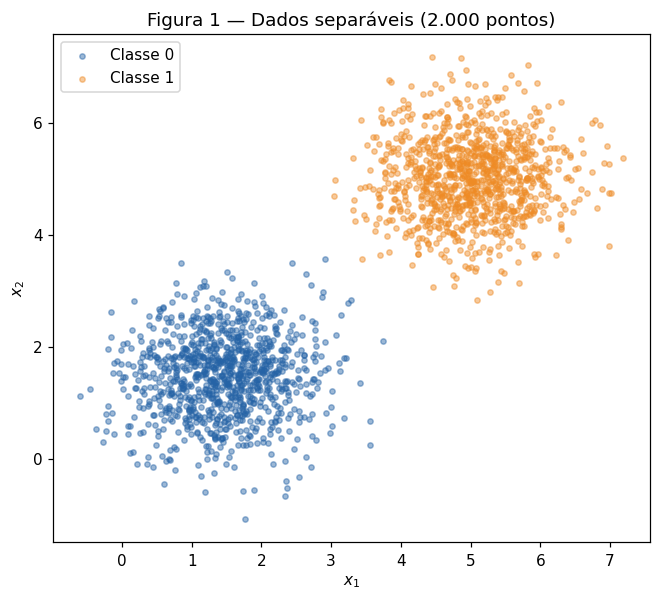

In [2]:
x1, y1 = make_dataset(rng, [1.5, 1.5], [5, 5], .5)
print('Formato:', x1.shape, '| contagens:', np.bincount(y1))
fig, ax = plt.subplots(figsize=(7, 6))
scatter_classes(ax, x1, y1)
ax.set_title('Figura 1 — Dados separáveis (2.000 pontos)')
plt.show()

## B — Implement the perceptron

`perceptron.py` define a ativação $z=\mathbf w\cdot\mathbf x+b$, a predição $\hat y=1[z\geq0]$ e a atualização $\Delta\mathbf w=\eta(y-\hat y)\mathbf x$, $\Delta b=\eta(y-\hat y)$. Um acerto tem erro zero. A inicialização é não nula e a parada ocorre após uma época sem erro ou 100 épocas. A acurácia total é registrada por época. Os rótulos 0/1 exigem $y-\hat y$; usar apenas $y$ nunca corrigiria um falso positivo da classe 0.

In [3]:
# O mesmo vetor inicial é reutilizado no item D para comparar somente eta.
w0 = rng.normal(0, 0.01, size=2)
fit1 = train(x1, y1, rng, eta=.01, initial_weights=w0)
print('Pesos iniciais:', w0)
print('Atualizações por época:', fit1.updates)

Pesos iniciais: [0.00253205 0.00895218]
Atualizações por época: [3, 3, 4, 4, 3, 4, 3, 4, 2, 4, 2, 4, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 1, 0]


## C — Train and measure

Foram **26 épocas** até convergir. Resultado: $\mathbf w=[0{,}050497,0{,}028872]$, $b=-0{,}250000$ e **100,00%** de acurácia. A Figura 2 marca erros com círculos vermelhos, quando existirem. A Figura 3 acompanha a acurácia em cada época.

Épocas: 26; w=[0.05049707 0.02887168]; b=-0.250000; acurácia=100.00%


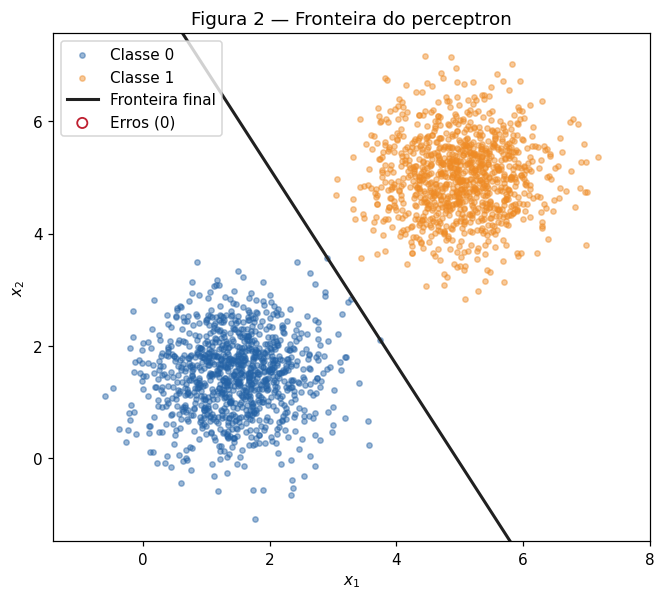

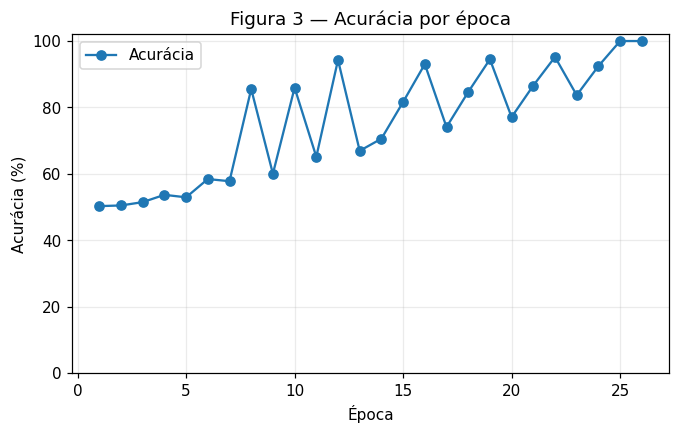

In [4]:
print(f'Épocas: {fit1.epochs}; w={fit1.weights}; b={fit1.bias:.6f}; acurácia={fit1.accuracies[-1]:.2%}')
fig, ax = plt.subplots(figsize=(7, 6))
scatter_classes(ax, x1, y1)
boundary(ax, fit1.weights, fit1.bias, ax.get_xlim(), 'Fronteira final')
mark_errors(ax, x1, y1, fit1.weights, fit1.bias)
ax.set_ylim(x1[:, 1].min()-.4, x1[:, 1].max()+.4)
ax.set_title('Figura 2 — Fronteira do perceptron')
ax.legend()
plt.show()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, fit1.epochs+1), np.array(fit1.accuracies)*100, marker='o', label='Acurácia')
ax.set(xlabel='Época', ylabel='Acurácia (%)', title='Figura 3 — Acurácia por época')
ax.set_ylim(0, 102)
ax.legend(); ax.grid(alpha=.25)
plt.show()

## D — Analysis

1. A cada erro, a atualização tenta corrigir a amostra. Como este conjunto admite uma reta separadora, os erros acabam: houve **3** atualizações na primeira época, **1** na penúltima e **0** na 26ª. A quantidade pode oscilar antes de chegar a zero.
2. Repetimos com $\eta=1{,}0$ e o **mesmo** `w0`. O resultado é **37 épocas**, **100,00%**, $\mathbf w=[5{,}870616,3{,}359239]$ e $b=-31$. As direções unitárias são $[0{,}868123,0{,}496349]$ e $[0{,}867950,0{,}496652]$. A taxa muda o tamanho das atualizações em relação ao vetor inicial de ordem $0{,}01$, alterando o caminho de treino e a reta obtida.
3. Se $\theta_0=(\mathbf w_0,b_0)=0$ e $\tilde x=(x,1)$, então $\theta_{t+1}^{(j)}=\theta_t^{(j)}+\eta_j e_t\tilde x_t$. Por indução, $\theta_t^{(2)}=(\eta_2/\eta_1)\theta_t^{(1)}$, pois o fator positivo mantém os sinais das ativações, os erros e as atualizações iguais nas duas execuções. Logo, ambas têm a mesma fronteira e época de parada.

In [5]:
fit1_eta1 = train(x1, y1, rng, eta=1.0, initial_weights=w0)
for eta, fit in ((.01, fit1), (1.0, fit1_eta1)):
    direction = fit.weights / np.linalg.norm(fit.weights)
    print(f'eta={eta}: épocas={fit.epochs}, acurácia={fit.accuracies[-1]:.2%}, w={fit.weights}, b={fit.bias:.6f}, direção={direction}')

eta=0.01: épocas=26, acurácia=100.00%, w=[0.05049707 0.02887168], b=-0.250000, direção=[0.86812305 0.49634905]
eta=1.0: épocas=37, acurácia=100.00%, w=[5.87061596 3.3592393 ], b=-31.000000, direção=[0.86794992 0.49665172]
